In [1]:
%autosave 60

Autosaving every 60 seconds


# Домашнее задание EDA | МТС Тета
-----
- Нужно провести EDA любого датасета на ваше усмотрение в специально подготовленном ipynb
- В этом ноутбуке будут блоки под разные типы графиков
- Нужно выбрать такой датасет, который позволит построить каждый из этих графиков корректно
- В ноутбуке так же будет дополнительное поле для графика на ваш выбор. В нем должен быть график, который не был построен ранее в ноутбуке (другой тип графика)
- Ноутбук должен отбегать в режиме run all, а так же сохранять все изображения шаблонным образом, как заложено в ноутбуке
- Для каждого графика должны быть написаны выводы
- __Вместе с ноутбуком нужно сдать сохраненные изображения (проверьте корректность их сохранения перед отправкой ДЗ)__
- изображения должны быть в формате png или jpeg. Не сохраняйте изображения в html (так делает plotly)
____
**Критерии оценки**
- Вы построили все основные графики без критических ошибок – 8 баллов
- Вы выполнили пункт 1, а так же построили дополнительный график - 10 баллов
- Доп. баллы выставляются за победу в tinder игре – подробности будут позже. Но чтобы в ней победить, ваш график должен оказаться самым красивым. 
- Доп. Баллы получат топ 10 человек итогового рейтинга. 
---
- Максимум 10 баллов (и +5 дополнительных)
- 1-4 балла: незачет
- 5-6 баллов: 3, незачет
- 7-8 баллов: 4, зачет
- 9-10 баллов: 5, зачет

## подготовка

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import seaborn as sns

In [5]:
# подставьте ваше имя и фамилию в эту переменную как в примере, (например Максим_Шаланкин)
image_name_prefix = 'Виталий_Краснощеков'

# можно поменять, а можно оставить - сюда будут сохраняться изображения
path_to_save_images = 'images'

In [6]:
os.makedirs(path_to_save_images, exist_ok=True)

In [24]:
df = pd.read_csv('tested.csv')
df = df[['PassengerId','Survived','Pclass','Sex','Age','SibSp','Fare']]
df.rename(columns={'Survived':'target'}, inplace=True)
df.set_index('PassengerId', inplace=True)
df.head()

,target,Pclass,Sex,Age,SibSp,Fare
PassengerId,,,,,,
892,0,3,male,34.5,0,7.8292
893,1,3,female,47.0,1,7.0000
894,0,2,male,62.0,0,9.6875
895,0,3,male,27.0,0,8.6625
896,1,3,female,22.0,1,12.2875


Я взял датасет, о выживаемости людей на Титанике, оставил только поля, кроме поля выжил/не выжил: класс билета, пол, возраст, кол-во родственников на корабле и стоимость билета.

## (1) line plot

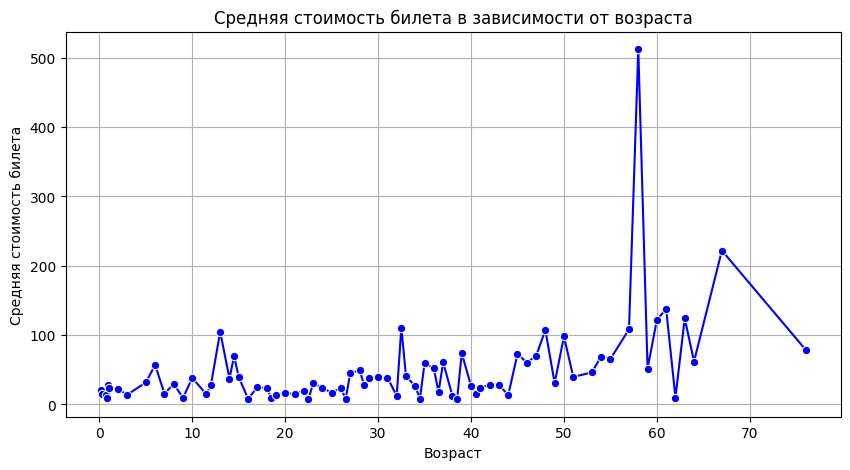

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df.groupby("Age")["Fare"].mean().reset_index(), x="Age", y="Fare", marker="o", color="blue")

plt.xlabel("Возраст")
plt.ylabel("Средняя стоимость билета")
plt.title("Средняя стоимость билета в зависимости от возраста")
plt.grid(True)

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_1.png')
)
plt.show()

#### Выводы: 
1. Виден выброс стоимости у пассажира с возрастом ~58 лет. 
2. Примерно с 45 годов средняя стоимость билетов пассажиров, чем у людей моложе 45. Возможно пожилые люди чаще покупали билеты более высоким классом.

## (2) (bar plot или stacked bar plot)

C:\Users\krasn\AppData\Local\Temp\ipykernel_6484\1488504632.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=diff_counts.index, y=diff_counts.values, palette=colors)
C:\Users\krasn\AppData\Local\Temp\ipykernel_6484\1488504632.py:9: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x=diff_counts.index, y=diff_counts.values, palette=colors)


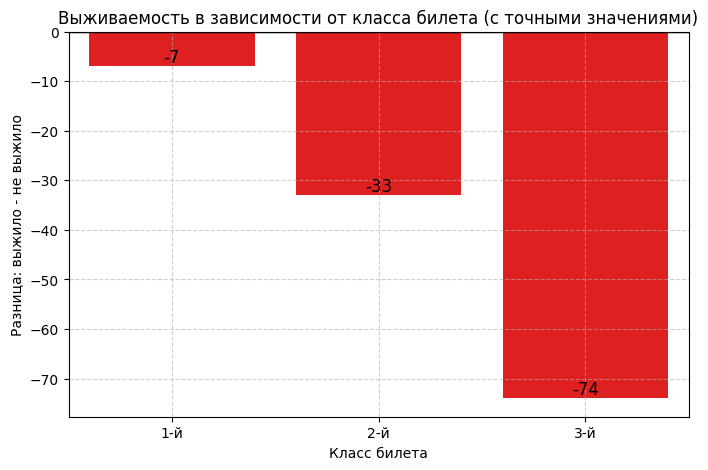

In [10]:
# Подсчет выживших - невыживших по классам
diff_counts = 2*df.groupby("Pclass")["target"].sum() - df.groupby("Pclass")["target"].count()

# Цвета: зелёный, если положительное значение, красный - если отрицательное
colors = np.where(diff_counts > 0, "green", "red")

# Построение вертикального Bar Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=diff_counts.index, y=diff_counts.values, palette=colors)

# Добавление подписей на столбцы
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel("Класс билета")
plt.ylabel("Разница: выжило - не выжило")
plt.title("Выживаемость в зависимости от класса билета (с точными значениями)")
plt.xticks([0, 1, 2], ["1-й", "2-й", "3-й"])
plt.axhline(0, color="black", linewidth=1)  # Линия нуля
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_2.png')
)

plt.show()

#### выводы:
1. Все значения отрицательные, что означает, что в каждом классе погибло больше людей, чем выжило.
2. Пассажиры 1-го класса имели наивысшие шансы на выживание. Пассажиры 3-го класса находились в наихудших условиях и у них был минимальный шанс спастись.

##  (3) (hist plot или pair plot или kde plot)

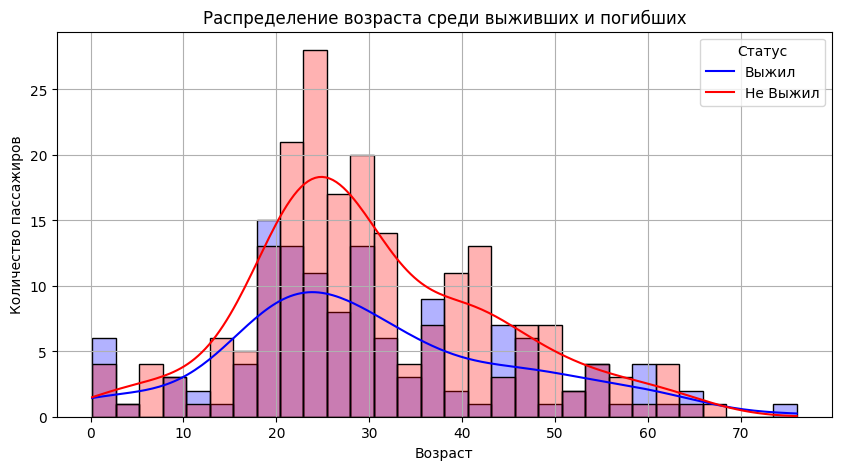

In [11]:
# Hist Plot: Распределение возраста среди выживших и невыживших с красным и зеленым цветами
plt.figure(figsize=(10, 5))
sns.histplot(df, x="Age", hue="target", kde=True, bins=30, palette={1: "blue", 0: "red"}, alpha=0.3)

plt.xlabel("Возраст")
plt.ylabel("Количество пассажиров")
plt.title("Распределение возраста среди выживших и погибших")
plt.legend(title="Статус", labels=["Выжил", "Не Выжил"])
plt.grid(True)

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_3.png')
)
plt.show()

#### Выводы:
1. Больше всего пассажиров было в возрасте от 18 до 42, что может объясняться, что этого возраста были люди обслуживающего персонала. 
2. Смертность и выживаемость на конца графиках сходятся. Это может быть обусловлена тем, что во-первых первыми спасали детей, а во-вторых, что люди более почтенного возраста имели билеты 1-го класса, который был лучшим повыживаемость(см. предыдущий график).
3. Также самая большая смертность была среди людей в возрасте от 20 до 30 лет. Скорее всего это были люди из 3-го класса(если см. средную стоимость билетов в этом возрасте) и персонал корабля, который в основном были мужчины в то время, которых спасали последними.  

##  (4) heatmap plot

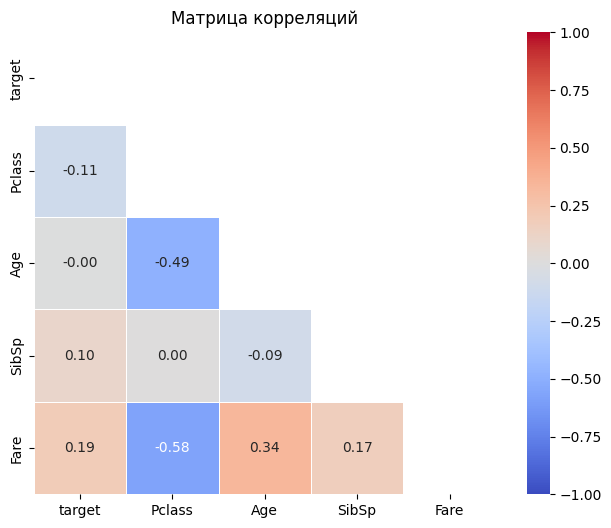

In [20]:
# Heatmap Plot: Корреляция между числовыми переменными
plt.figure(figsize=(8, 6))

corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, square=True, cbar=True)

plt.title("Матрица корреляций")
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_4.png')
)
plt.show()

#### выводы:
1. Мы видим сильную отрицательную кореляцию класса билета с возрастом и стоимостью. Чем выше класса(ближе к 1-ому), тем дороже билет, это звучит логично. Еще можно сказать, что молодые пассажиры чаще покупали билеты более низкого класса, а в 1-м классе больше пожилых пассажиров.
2. Если говорить о выживаемости, то она точно не линейно зависима от возраста. Но у нее большая корреляция с ценой билета.

##  (5) plot  на ваш выбор

C:\Users\krasn\AppData\Local\Temp\ipykernel_6484\2190995719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="pastel", width=0.6, showfliers=False)


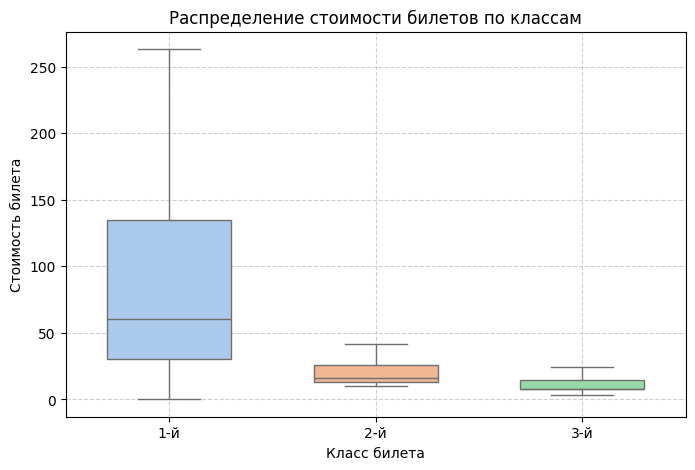

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Pclass", y="Fare", data=df, palette="pastel", width=0.6, showfliers=False)

plt.xlabel("Класс билета")
plt.ylabel("Стоимость билета")
plt.title("Распределение стоимости билетов по классам")
plt.xticks([0, 1, 2], ["1-й", "2-й", "3-й"])
plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_5.png')
)
plt.show()



#### выводы:
1. Очевидный вывод, чем выше класс(ближе к 1-ому), тем дороже билет.
2. Но у 1-го класса широкий разброс цен. Это может объясняться, тем, что билет в 1-й класс можно было получить в подарок от компании владеющей титаником или за скидку. Можно допольнительно сделать boxplot по возрасту от класса, возможно все дети, у которых билет мог быть не полной стоимости, могли находиться в 1-м классе.  

# Итоговый вывод по всему датасету (по всему EDA)
Цена билета сильно зависела от класса, и это могло влиять на выживаемость: 1-й класс выживал чаще и дорогостоящие билеты давали больше шансов на спасение.
А также есть выброс в стоимости билета у человек с возрастом 58 лет.